In [46]:
import os
import glob
import json
import numpy as np
import pandas as pd

# ==========================================================
# CONFIG
# ==========================================================

NSEI_DIR = "../Main/minute_data/NSEI/"
VIX_DIR  = "../Main/minute_data/INDIAVIX/"

OOS_OUTPUT_FILE = "../Main/minute_data/dataset_intraday_OOS.csv"

TP_RANGE = range(9, 26)
SL_RATIO = 0.5
LOOKAHEAD = 45
MARKET_MINUTES = 375

# ------------------------------
# OOS SELECTION MODE
# ------------------------------

MODE = "latest_n"   # "latest_n" or "specific_dates"
LATEST_N = 2

SPECIFIC_DATES = ["2024-02-16", "2024-02-17"]


# ==========================================================
# LOADING
# ==========================================================

def load_csv(path):
    df = pd.read_csv(path)

    df.columns = df.columns.str.lower()
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)

    df = df.drop(columns=["volume"], errors="ignore")
    df = df.sort_values("datetime").reset_index(drop=True)

    return df


def minutes_from_open(df):
    open_time = df["datetime"].dt.normalize() + pd.Timedelta(hours=9, minutes=15)
    return ((df["datetime"] - open_time).dt.total_seconds() / 60)


# ==========================================================
# NSEI FEATURES
# ==========================================================

def build_nsei_features(df):

    df["ret_1"] = df["close"].pct_change()
    df["ret_3"] = df["close"].pct_change(3)

    df["range"] = df["high"] - df["low"]

    df["rv_10"] = df["ret_1"].rolling(10).std()
    df["rv_ratio"] = df["rv_10"] / df["rv_10"].rolling(30).mean()

    abs_sum = df["ret_1"].abs().rolling(10).sum()
    net_move = df["close"].diff(10).abs()
    df["chop_ratio"] = net_move / abs_sum

    ema10 = df["close"].ewm(span=10).mean()
    ema30 = df["close"].ewm(span=30).mean()
    df["trend_strength"] = (ema10 - ema30) / df["close"]

    high15 = df["high"].rolling(15).max()
    low15  = df["low"].rolling(15).min()
    df["range_pos_15"] = (df["close"] - low15) / (high15 - low15)

    high30 = df["high"].rolling(30).max()
    low30  = df["low"].rolling(30).min()
    df["range_pos_30"] = (df["close"] - low30) / (high30 - low30)

    df["minutes_from_open"] = minutes_from_open(df)
    df["time_sin"] = np.sin(2 * np.pi * df["minutes_from_open"] / MARKET_MINUTES)
    df["time_cos"] = np.cos(2 * np.pi * df["minutes_from_open"] / MARKET_MINUTES)

    return df


# ==========================================================
# VIX FEATURES
# ==========================================================

def build_vix_features(df):

    df["vix_ret_1"] = df["close"].pct_change()
    df["vix_ret_5"] = df["close"].pct_change(5)

    df["vix_rv_10"] = df["vix_ret_1"].rolling(10).std()
    df["vix_vol_ratio"] = df["vix_rv_10"] / df["vix_rv_10"].rolling(30).mean()

    return df


# ==========================================================
# TARGETS
# ==========================================================

def build_targets(df):

    future_high = df["high"].rolling(LOOKAHEAD).max().shift(-LOOKAHEAD)
    future_low  = df["low"].rolling(LOOKAHEAD).min().shift(-LOOKAHEAD)

    entry = df["close"]

    for tp in TP_RANGE:
        sl = tp * SL_RATIO

        df[f"y_call_{tp}"] = (
            (future_high - entry >= tp) &
            (entry - future_low <= sl)
        ).astype(int)

        df[f"y_put_{tp}"] = (
            (entry - future_low >= tp) &
            (future_high - entry <= sl)
        ).astype(int)

    return df


# ==========================================================
# HELPERS
# ==========================================================

def extract_date_from_filename(path):
    name = os.path.basename(path)
    return name.split("_")[-1].replace(".csv", "")


def build_vix_lookup():
    vix_files = glob.glob(os.path.join(VIX_DIR, "*.csv"))
    lookup = {}
    for path in vix_files:
        date = extract_date_from_filename(path)
        lookup[date] = path
    return lookup


# ==========================================================
# MAIN OOS PIPELINE
# ==========================================================

def process_oos_days():

    nsei_files = sorted(glob.glob(os.path.join(NSEI_DIR, "*.csv")))
    vix_lookup = build_vix_lookup()

    print(f"Found {len(nsei_files)} NSEI files")

    # ---------------------------------
    # Select OOS dates
    # ---------------------------------

    all_dates = [extract_date_from_filename(p) for p in nsei_files]
    all_dates_sorted = sorted(all_dates)

    if MODE == "latest_n":
        selected_dates = all_dates_sorted[-LATEST_N:]

    elif MODE == "specific_dates":
        selected_dates = SPECIFIC_DATES

    else:
        raise ValueError("Invalid MODE")

    print("Selected OOS dates:", selected_dates)

    all_days = []

    for nsei_path in nsei_files:

        date_str = extract_date_from_filename(nsei_path)

        if date_str not in selected_dates:
            continue

        if date_str not in vix_lookup:
            print(f"⚠ No VIX file for {date_str}")
            continue

        nsei = load_csv(nsei_path)
        vix  = load_csv(vix_lookup[date_str])

        if len(nsei) < 200:
            print(f"⚠ Skipping {date_str} (too few rows)")
            continue

        nsei = build_nsei_features(nsei)
        vix  = build_vix_features(vix)

        df = pd.merge(
            nsei,
            vix[["datetime", "vix_ret_1", "vix_ret_5",
                 "vix_rv_10", "vix_vol_ratio"]],
            on="datetime",
            how="inner"
        )

        if len(df) == 0:
            print(f"⚠ Empty merge for {date_str}")
            continue

        df["price_vix_div"] = df["ret_1"] - df["vix_ret_1"]

        df = build_targets(df)

        df = df.iloc[40:-LOOKAHEAD]
        df["date"] = df["datetime"].dt.date
        df = df.dropna()

        if len(df) == 0:
            print(f"⚠ Empty after dropna for {date_str}")
            continue

        all_days.append(df)
        print(f"✅ Processed {date_str} ({len(df)} rows)")

    if len(all_days) == 0:
        print("❌ No valid OOS days processed.")
        return

    final_df = pd.concat(all_days).reset_index(drop=True)

    # ---------------------------------
    # Organize columns
    # ---------------------------------

    base_cols = ["datetime", "date", "close", "high", "low"]

    target_cols = [c for c in final_df.columns if c.startswith("y_")]

    feature_cols = [
        c for c in final_df.columns
        if c not in base_cols
        and c not in target_cols
        and c not in ["open", "volume"]
    ]

    final_df = final_df[base_cols + feature_cols + target_cols]
    final_df = final_df.sort_values("datetime").reset_index(drop=True)

    final_df.to_csv(OOS_OUTPUT_FILE, index=False)

    meta = {
        "mode": MODE,
        "selected_dates": selected_dates,
        "tp_range": list(TP_RANGE),
        "sl_ratio": SL_RATIO,
        "lookahead": LOOKAHEAD,
        "feature_count": len(feature_cols),
        "target_count": len(target_cols)
    }

    meta_path = OOS_OUTPUT_FILE.replace(".csv", "_meta.json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=4)

    print("\nSaved OOS dataset to:", OOS_OUTPUT_FILE)
    print("Saved metadata to:", meta_path)
    print("Total OOS rows:", len(final_df))
    print("Feature count:", len(feature_cols))
    print("Target count:", len(target_cols))


if __name__ == "__main__":
    process_oos_days()

Found 49 NSEI files
Selected OOS dates: ['2026-02-13', '2026-02-16']
✅ Processed 2026-02-13 (290 rows)
✅ Processed 2026-02-16 (290 rows)

Saved OOS dataset to: ../Main/minute_data/dataset_intraday_OOS.csv
Saved metadata to: ../Main/minute_data/dataset_intraday_OOS_meta.json
Total OOS rows: 580
Feature count: 17
Target count: 34


In [30]:
import os
import glob
import json
import numpy as np
import pandas as pd

# ==========================================================
# CONFIG (MOMENTUM STRUCTURE)
# ==========================================================

NSEI_DIR = "../Main/minute_data/NSEI/"
VIX_DIR  = "../Main/minute_data/INDIAVIX/"
OUTPUT_FILE = "../Main/minute_data/dataset_intraday_t.csv"

TP_RANGE = range(9, 26)   # 15 to 25 inclusive
SL_RATIO = 0.5             # SL = TP * 0.5
LOOKAHEAD = 45
MARKET_MINUTES = 375       # 9:15 to 15:30


# ==========================================================
# LOADING
# ==========================================================

def load_csv(path):
    df = pd.read_csv(path)

    df.columns = df.columns.str.lower()
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)

    df = df.drop(columns=["volume"], errors="ignore")

    df = df.sort_values("datetime").reset_index(drop=True)
    return df


def minutes_from_open(df):
    open_time = df["datetime"].dt.normalize() + pd.Timedelta(hours=9, minutes=15)
    return ((df["datetime"] - open_time).dt.total_seconds() / 60)


# ==========================================================
# NSEI FEATURES
# ==========================================================

def build_nsei_features(df):

    df["ret_1"] = df["close"].pct_change()
    df["ret_3"] = df["close"].pct_change(3)

    df["range"] = df["high"] - df["low"]

    df["rv_10"] = df["ret_1"].rolling(10).std()
    df["rv_ratio"] = df["rv_10"] / df["rv_10"].rolling(30).mean()

    abs_sum = df["ret_1"].abs().rolling(10).sum()
    net_move = df["close"].diff(10).abs()
    df["chop_ratio"] = net_move / abs_sum

    ema10 = df["close"].ewm(span=10).mean()
    ema30 = df["close"].ewm(span=30).mean()
    df["trend_strength"] = (ema10 - ema30) / df["close"]

    high15 = df["high"].rolling(15).max()
    low15  = df["low"].rolling(15).min()
    df["range_pos_15"] = (df["close"] - low15) / (high15 - low15)

    high30 = df["high"].rolling(30).max()
    low30  = df["low"].rolling(30).min()
    df["range_pos_30"] = (df["close"] - low30) / (high30 - low30)

    df["minutes_from_open"] = minutes_from_open(df)
    df["time_sin"] = np.sin(2 * np.pi * df["minutes_from_open"] / MARKET_MINUTES)
    df["time_cos"] = np.cos(2 * np.pi * df["minutes_from_open"] / MARKET_MINUTES)

    return df


# ==========================================================
# VIX FEATURES
# ==========================================================

def build_vix_features(df):

    df["vix_ret_1"] = df["close"].pct_change()
    df["vix_ret_5"] = df["close"].pct_change(5)

    df["vix_rv_10"] = df["vix_ret_1"].rolling(10).std()
    df["vix_vol_ratio"] = df["vix_rv_10"] / df["vix_rv_10"].rolling(30).mean()

    return df


# ==========================================================
# TARGETS (Momentum Structure)
# ==========================================================

def build_targets(df):

    future_high = df["high"].rolling(LOOKAHEAD).max().shift(-LOOKAHEAD)
    future_low  = df["low"].rolling(LOOKAHEAD).min().shift(-LOOKAHEAD)

    entry = df["close"]

    for tp in TP_RANGE:
        sl = tp * SL_RATIO

        df[f"y_call_{tp}"] = (
            (future_high - entry >= tp) &
            (entry - future_low <= sl)
        ).astype(int)

        df[f"y_put_{tp}"] = (
            (entry - future_low >= tp) &
            (future_high - entry <= sl)
        ).astype(int)

    return df


# ==========================================================
# FILE HELPERS
# ==========================================================

def extract_date_from_filename(path):
    name = os.path.basename(path)
    return name.split("_")[-1].replace(".csv", "")


def build_vix_lookup():
    vix_files = glob.glob(os.path.join(VIX_DIR, "*.csv"))
    lookup = {}
    for path in vix_files:
        date = extract_date_from_filename(path)
        lookup[date] = path
    return lookup


# ==========================================================
# MAIN PIPELINE
# ==========================================================

def process_all_days():

    nsei_files = sorted(glob.glob(os.path.join(NSEI_DIR, "*.csv")))
    vix_lookup = build_vix_lookup()

    print(f"Found {len(nsei_files)} NSEI files")
    print(f"Found {len(vix_lookup)} VIX files")

    all_days = []

    for nsei_path in nsei_files:

        date_str = extract_date_from_filename(nsei_path)

        if date_str not in vix_lookup:
            print(f"⚠ No VIX file for {date_str}")
            continue

        nsei = load_csv(nsei_path)
        vix  = load_csv(vix_lookup[date_str])

        if len(nsei) < 200:
            print(f"⚠ Skipping {date_str} (too few rows)")
            continue

        nsei = build_nsei_features(nsei)
        vix  = build_vix_features(vix)

        df = pd.merge(
            nsei,
            vix[["datetime", "vix_ret_1", "vix_ret_5",
                 "vix_rv_10", "vix_vol_ratio"]],
            on="datetime",
            how="inner"
        )

        if len(df) == 0:
            print(f"⚠ Empty merge for {date_str}")
            continue

        df["price_vix_div"] = df["ret_1"] - df["vix_ret_1"]

        df = build_targets(df)

        df = df.iloc[40:-LOOKAHEAD]
        df["date"] = df["datetime"].dt.date
        df = df.dropna()

        if len(df) == 0:
            print(f"⚠ Empty after dropna for {date_str}")
            continue

        all_days.append(df)
        print(f"✅ Processed {date_str} ({len(df)} rows)")

    if len(all_days) == 0:
        print("❌ No valid days processed.")
        return

    final_df = pd.concat(all_days).reset_index(drop=True)

    # ======================================================
    # CLEAN & ORGANIZE FINAL DATASET
    # ======================================================

    base_cols = ["datetime", "date", "close", "high", "low"]

    target_cols = [c for c in final_df.columns if c.startswith("y_")]

    feature_cols = [
        c for c in final_df.columns
        if c not in base_cols
        and c not in target_cols
        and c not in ["open", "volume"]
    ]

    final_df = final_df[base_cols + feature_cols + target_cols]
    final_df = final_df.sort_values("datetime").reset_index(drop=True)

    final_df.to_csv(OUTPUT_FILE, index=False)

    # Save metadata
    meta = {
        "tp_range": list(TP_RANGE),
        "sl_ratio": SL_RATIO,
        "lookahead": LOOKAHEAD,
        "feature_count": len(feature_cols),
        "target_count": len(target_cols)
    }

    meta_path = OUTPUT_FILE.replace(".csv", "_meta.json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=4)

    print("\nSaved dataset to:", OUTPUT_FILE)
    print("Saved metadata to:", meta_path)
    print("Total rows:", len(final_df))
    print("Feature count:", len(feature_cols))
    print("Target count:", len(target_cols))


if __name__ == "__main__":
    process_all_days()

Found 48 NSEI files
Found 48 VIX files
✅ Processed 2025-11-25 (290 rows)
✅ Processed 2025-11-26 (284 rows)
✅ Processed 2025-11-27 (290 rows)
✅ Processed 2025-11-28 (290 rows)
✅ Processed 2025-12-01 (290 rows)
✅ Processed 2025-12-02 (290 rows)
✅ Processed 2025-12-03 (290 rows)
✅ Processed 2025-12-04 (284 rows)
✅ Processed 2025-12-05 (290 rows)
✅ Processed 2025-12-08 (290 rows)
✅ Processed 2025-12-09 (290 rows)
✅ Processed 2025-12-10 (290 rows)
✅ Processed 2025-12-11 (290 rows)
✅ Processed 2025-12-12 (290 rows)
✅ Processed 2025-12-15 (290 rows)
✅ Processed 2025-12-16 (290 rows)
✅ Processed 2025-12-17 (290 rows)
✅ Processed 2025-12-26 (290 rows)
✅ Processed 2025-12-29 (290 rows)
✅ Processed 2025-12-30 (290 rows)
✅ Processed 2025-12-31 (290 rows)
✅ Processed 2026-01-01 (290 rows)
✅ Processed 2026-01-02 (290 rows)
✅ Processed 2026-01-05 (290 rows)
✅ Processed 2026-01-06 (289 rows)
✅ Processed 2026-01-07 (290 rows)
✅ Processed 2026-01-08 (290 rows)
✅ Processed 2026-01-09 (290 rows)
✅ Process

In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# ==========================================================
# CONFIG
# ==========================================================

DATA_PATH = "../Main/minute_data/dataset_intraday_t.csv"
TP = 10
MODEL_OUTPUT = f"put_model_tp{TP}.pkl"

TRAIN_RATIO = 0.6

# Small but effective grid
PARAM_GRID = {
    "n_estimators": [200],
    "max_depth": [4, 6],
    "min_samples_leaf": [40, 60],
}

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

target_col = f"y_put_{TP}"

if target_col not in df.columns:
    raise ValueError(f"{target_col} not found in dataset.")

# Remove all targets from feature space
target_cols = [c for c in df.columns if c.startswith("y_")]

feature_cols = [
    c for c in df.columns
    if c not in target_cols
    and c not in ["datetime", "date", "close", "high", "low"]
]

X = df[feature_cols]
y = df[target_col]

print("Total samples:", len(df))
print("Positive rate:", y.mean())

# ==========================================================
# TIME SPLIT (NO SHUFFLE)
# ==========================================================

split_index = int(len(df) * TRAIN_RATIO)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ==========================================================
# MODEL TRAINING
# ==========================================================

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

grid = GridSearchCV(
    rf,
    PARAM_GRID,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# ==========================================================
# TEST PERFORMANCE
# ==========================================================

test_probs = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)

print("Test AUC:", test_auc)

# ==========================================================
# SAVE MODEL
# ==========================================================

# Attach feature names to model for safe inference
best_model.feature_names_in_ = np.array(feature_cols)

joblib.dump(best_model, MODEL_OUTPUT)
joblib.dump(feature_cols, f"put_model_tp{TP}_features.pkl")

print("\nModel saved as:", MODEL_OUTPUT)
print("Feature count:", len(feature_cols))

Total samples: 13785
Positive rate: 0.1347841857091041
Train size: 8271
Test size: 5514

Best Params: {'max_depth': 6, 'min_samples_leaf': 60, 'n_estimators': 200}
Best CV AUC: 0.596520222425929
Test AUC: 0.6048904854620141

Model saved as: put_model_tp10.pkl
Feature count: 17


In [34]:
import pandas as pd
import numpy as np
import joblib

# ==========================================================
# CONFIG
# ==========================================================

DATA_PATH = "../Main/minute_data/dataset_intraday_t.csv"
MODEL_PATH = "put_model_tp10.pkl"

TP = 10
SL = 5
THRESHOLD = 0.65
MAX_HOLD_BARS = 4

LOT_SIZE = 75
LOTS = 3
BROKERAGE = 85
OPTION_MULTIPLIER = 0.5   # Approx ATM delta


# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Remove target columns
target_cols = [c for c in df.columns if c.startswith("y_")]

feature_cols = [
    c for c in df.columns
    if c not in target_cols
    and c not in ["datetime", "date", "close", "high", "low"]
]

X = df[feature_cols]

# ==========================================================
# LOAD MODEL & GENERATE PREDICTIONS
# ==========================================================

model = joblib.load(MODEL_PATH)

# Align feature order exactly as model expects
X = X[model.feature_names_in_]

df["prob_put"] = model.predict_proba(X)[:, 1]

print("Predictions generated successfully.")


# ==========================================================
# SIMULATION
# ==========================================================

trades = []
i = 0

while i < len(df) - MAX_HOLD_BARS:

    if df.loc[i, "prob_put"] >= THRESHOLD:

        entry_price = df.loc[i, "close"]
        entry_time = df.loc[i, "datetime"]

        exit_price = None
        exit_time = None
        reason = None

        for j in range(1, MAX_HOLD_BARS + 1):

            future_low = df.loc[i + j, "low"]
            future_high = df.loc[i + j, "high"]

            favorable_move = entry_price - future_low
            adverse_move = future_high - entry_price

            # ---- TAKE PROFIT ----
            if favorable_move >= TP:
                exit_price = entry_price - TP
                exit_time = df.loc[i + j, "datetime"]
                reason = "TP"
                i += j
                break

            # ---- STOP LOSS ----
            if adverse_move >= SL:
                exit_price = entry_price + SL
                exit_time = df.loc[i + j, "datetime"]
                reason = "SL"
                i += j
                break

        # ---- TIME EXIT ----
        if exit_price is None:
            exit_price = df.loc[i + MAX_HOLD_BARS, "close"]
            exit_time = df.loc[i + MAX_HOLD_BARS, "datetime"]
            reason = "TIME"
            i += MAX_HOLD_BARS

        # ---- PnL CALCULATION ----
        index_move = exit_price - entry_price
        option_points = -index_move * OPTION_MULTIPLIER

        gross = option_points * LOT_SIZE * LOTS
        net = gross - BROKERAGE

        trades.append({
            "entry_time": entry_time,
            "exit_time": exit_time,
            "entry_index": entry_price,
            "exit_index": exit_price,
            "probability": df.loc[i, "prob_put"],
            "reason": reason,
            "gross": gross,
            "net": net
        })

    else:
        i += 1


trades = pd.DataFrame(trades)

# ==========================================================
# PERFORMANCE REPORT
# ==========================================================

if len(trades) == 0:
    print("No trades generated.")
else:
    trades["equity"] = trades["net"].cumsum()
    trades["cum_max"] = trades["equity"].cummax()
    trades["drawdown"] = trades["cum_max"] - trades["equity"]

    total_trades = len(trades)
    win_rate = (trades["net"] > 0).mean()
    total_pnl = trades["net"].sum()
    avg_pnl = trades["net"].mean()
    max_dd = trades["drawdown"].max()

    print("\n========== PERFORMANCE ==========")
    print(f"TP: {TP}")
    print(f"SL: {SL}")
    print(f"Threshold: {THRESHOLD}")
    print(f"Lots: {LOTS}")
    print(f"Total Trades: {total_trades}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total PnL: ₹{total_pnl:,.2f}")
    print(f"Avg PnL per trade: ₹{avg_pnl:,.2f}")
    print(f"Max Drawdown: ₹{max_dd:,.2f}")
    print("=================================\n")

    print("Exit Distribution:")
    print(trades["reason"].value_counts())

    trades.to_csv("put_micro_scalp_results.csv", index=False)

Predictions generated successfully.

========== PERFORMANCE ==========
TP: 10
SL: 5
Threshold: 0.65
Lots: 3
Total Trades: 196
Win Rate: 57.14%
Total PnL: ₹35,641.51
Avg PnL per trade: ₹181.84
Max Drawdown: ₹10,232.72

Exit Distribution:
reason
SL      69
TIME    66
TP      61
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import joblib

# ==========================================================
# CONFIG
# ==========================================================

DATA_PATH = "../Main/minute_data/dataset_intraday_t.csv"
MODEL_PATH = "put_model_tp10.pkl"

# TP = 10
# SL = 5
THRESHOLD = 0.65
# MAX_HOLD_BARS = 10

LOT_SIZE = 75
LOTS = 3
BROKERAGE = 85
OPTION_MULTIPLIER = 0.5

MIN_LOCK = 4
# TRAIL_TRIGGER = 6
# TRAIL_GAP = 4

# ==========================================================
# LOAD DATA & MODEL
# ==========================================================

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

target_cols = [c for c in df.columns if c.startswith("y_")]
feature_cols = [
    c for c in df.columns
    if c not in target_cols
    and c not in ["datetime", "date", "close", "high", "low"]
]

X = df[feature_cols]

model = joblib.load(MODEL_PATH)
X = X[model.feature_names_in_]
df["prob_put"] = model.predict_proba(X)[:, 1]

print("Predictions generated successfully.\n")

# ==========================================================
# GRID SEARCH CONFIG
# ==========================================================

TP_RANGE = range(8, 21, 2)              # 8,10,12,...20
SL_RATIOS = [0.4, 0.5, 0.6]             # SL = TP * ratio
HOLD_RANGE = range(4, 16, 2)            # 4,6,8,...14

MODE = "minlock"                        # Best performer

# ==========================================================
# SIMULATION ENGINE (PARAMETERIZED)
# ==========================================================

def run_simulation(tp, sl, hold, mode="basic"):

    trades = []
    i = 0

    while i < len(df) - hold:

        if df.loc[i, "prob_put"] >= THRESHOLD:

            entry_price = df.loc[i, "close"]
            dynamic_sl = sl
            best_move = 0
            exit_price = None

            for j in range(1, hold + 1):

                future_low = df.loc[i + j, "low"]
                future_high = df.loc[i + j, "high"]

                favorable = entry_price - future_low
                adverse = future_high - entry_price

                best_move = max(best_move, favorable)

                # --- BREAK EVEN ---
                if mode == "breakeven" and best_move >= MIN_LOCK:
                    dynamic_sl = 0

                # --- TRAILING ---
                if mode == "trailing" and best_move >= TRAIL_TRIGGER:
                    dynamic_sl = max(dynamic_sl, best_move - TRAIL_GAP)

                # --- TP ---
                if favorable >= tp:
                    exit_price = entry_price - tp
                    i += j
                    break

                # --- SL ---
                if adverse >= dynamic_sl:
                    exit_price = entry_price + dynamic_sl
                    i += j
                    break

            # --- TIME EXIT ---
            if exit_price is None:

                time_price = df.loc[i + hold, "close"]

                if mode == "minlock" and best_move >= MIN_LOCK:
                    exit_price = entry_price - MIN_LOCK
                else:
                    exit_price = time_price

                i += hold

            # --- PNL ---
            index_move = exit_price - entry_price
            option_points = -index_move * OPTION_MULTIPLIER
            gross = option_points * LOT_SIZE * LOTS
            net = gross - BROKERAGE

            trades.append(net)

        else:
            i += 1

    if len(trades) == 0:
        return None

    trades = pd.Series(trades)
    equity = trades.cumsum()
    drawdown = equity.cummax() - equity

    return {
        "Total Trades": len(trades),
        "Win Rate": (trades > 0).mean(),
        "Total PnL": trades.sum(),
        "Avg PnL": trades.mean(),
        "Max DD": drawdown.max(),
        "PnL/DD": trades.sum() / drawdown.max() if drawdown.max() != 0 else 0
    }


# ==========================================================
# GRID SEARCH LOOP
# ==========================================================

results = []

for tp in TP_RANGE:
    for ratio in SL_RATIOS:

        sl = tp * ratio

        for hold in HOLD_RANGE:

            res = run_simulation(tp, sl, hold, MODE)

            if res is not None:
                res["TP"] = tp
                res["SL"] = sl
                res["HOLD"] = hold
                results.append(res)

results_df = pd.DataFrame(results)

# Sort by robustness (not just PnL)
results_df = results_df.sort_values(
    by=["PnL/DD", "Total PnL"],
    ascending=False
)

print("\n========== GRID SEARCH RESULTS ==========\n")
print(results_df.head(15))
print("\n==========================================")

Predictions generated successfully.


========== GRID SEARCH RESULTS ==========

     Total Trades  Win Rate     Total PnL     Avg PnL       Max DD    PnL/DD  \
41            149  0.536913  49975.000000  335.402685  7670.000000  6.515645   
17            182  0.582418  38890.000000  213.681319  6035.000000  6.444076   
89            104  0.692308  41650.000000  400.480769  6510.000000  6.397849   
16            183  0.584699  38355.000000  209.590164  6035.000000  6.355427   
86            124  0.725806  43235.175781  348.670772  6945.000000  6.225367   
107            95  0.726316  45795.800781  482.061061  7365.000000  6.218031   
78            170  0.694118  32806.372070  192.978659  5321.655273  6.164693   
60            177  0.694915  35023.872070  197.874983  5707.324219  6.136654   
40            151  0.536424  47015.000000  311.357616  7670.000000  6.129726   
14            188  0.590426  37840.000000  201.276596  6295.000000  6.011120   
39            150  0.546667  45930.0000

In [10]:
import pandas as pd
import numpy as np
import joblib

# ==========================================================
# CONFIG
# ==========================================================

OOS_PATH = "../Main/minute_data/dataset_intraday_OOS.csv"

TP = 12
SL = 4.8
HOLD_BARS = 14
THRESHOLD = 0.65

ENTRY_START_TIME = "09:45:00"

MODEL_PATH = "put_model_tp10.pkl"
FEATURE_PATH = "put_model_tp10_features.pkl"

INITIAL_CAPITAL = 15000
MARGIN = 5
TRADE_COST = 85

# ==========================================================
# LOAD ARTIFACTS
# ==========================================================

model = joblib.load(MODEL_PATH)
feature_cols = joblib.load(FEATURE_PATH)

# ==========================================================
# LOAD OOS DATA
# ==========================================================

df = pd.read_csv(OOS_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Ensure feature integrity
missing = set(feature_cols) - set(df.columns)
if len(missing) > 0:
    raise ValueError(f"Missing features in OOS dataset: {missing}")

X = df[feature_cols]
df["prob_put"] = model.predict_proba(X)[:, 1]

# ==========================================================
# EXECUTION LOGIC
# ==========================================================

capital = INITIAL_CAPITAL
trade_logs = []

for date, day_df in df.groupby(df["datetime"].dt.date):

    day_df = day_df.reset_index(drop=True)

    # Filter after 09:45
    day_df = day_df[
        day_df["datetime"].dt.strftime("%H:%M:%S") >= ENTRY_START_TIME
    ].reset_index(drop=True)

    if len(day_df) == 0:
        continue

    # Find first signal above threshold
    signal_rows = day_df[day_df["prob_put"] >= THRESHOLD]

    if len(signal_rows) == 0:
        continue

    entry_index = signal_rows.index[0]
    entry_row = day_df.loc[entry_index]

    entry_price = entry_row["close"]
    entry_time = entry_row["datetime"]

    qty = (capital * MARGIN) / entry_price

    exit_price = None
    exit_time = None
    exit_reason = None

    # Monitor next HOLD_BARS
    for i in range(entry_index, min(entry_index + HOLD_BARS, len(day_df))):

        row = day_df.loc[i]

        # TP hit (price drops 12 points)
        if entry_price - row["low"] >= TP:
            exit_price = entry_price - TP
            exit_time = row["datetime"]
            exit_reason = "TP"
            break

        # SL hit (price rises 4.8 points)
        if row["high"] - entry_price >= SL:
            exit_price = entry_price + SL
            exit_time = row["datetime"]
            exit_reason = "SL"
            break

    # If neither hit → exit at last HOLD bar close
    if exit_price is None:
        last_bar_index = min(entry_index + HOLD_BARS - 1, len(day_df) - 1)
        last_row = day_df.loc[last_bar_index]
        exit_price = last_row["close"]
        exit_time = last_row["datetime"]
        exit_reason = "TIME"

    pnl = (entry_price - exit_price) * qty - TRADE_COST
    capital += pnl

    trade_logs.append({
        "date": date,
        "entry_time": entry_time,
        "exit_time": exit_time,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "prob": entry_row["prob_put"],
        "exit_reason": exit_reason,
        "pnl": pnl,
        "capital": capital
    })

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame(trade_logs)

print("\n========== OOS RESULTS ==========")

if len(results) == 0:
    print("No trades generated.")
else:
    win_rate = (results["pnl"] > 0).mean()
    total_pnl = results["pnl"].sum()
    max_dd = (results["capital"].cummax() - results["capital"]).max()

    print("Trades:", len(results))
    print("Win Rate:", round(win_rate, 4))
    print("Total PnL:", round(total_pnl, 2))
    print("Max Drawdown:", round(max_dd, 2))
    print("Final Capital:", round(capital, 2))

    print("\nExit Distribution:")
    print(results["exit_reason"].value_counts())

    results.to_csv("oos_put_trades_final.csv", index=False)
    print("\nTrade log saved: oos_put_trades_final.csv")

print("=================================")


========== OOS RESULTS ==========
Trades: 2
Win Rate: 0.0
Total PnL: -198.11
Max Drawdown: 99.02
Final Capital: 14801.89

Exit Distribution:
exit_reason
SL    2
Name: count, dtype: int64

Trade log saved: oos_put_trades_final.csv


In [ ]:
# import pandas as pd
# import numpy as np
# import os

# def process_nsei_file(filepath):
#     df = pd.read_csv(filepath)

#     # --- Datetime ---
#     df["Datetime"] = pd.to_datetime(df["Datetime"])
#     df = df.sort_values("Datetime")
#     df.set_index("Datetime", inplace=True)

#     # --- Rename to lowercase (safer) ---
#     df.columns = df.columns.str.lower()

#     # --- Returns ---
#     df["ret_1"] = np.log(df["close"] / df["close"].shift(1))
#     df["ret_3"] = np.log(df["close"] / df["close"].shift(3))

#     # --- Candle structure ---
#     df["range"] = df["high"] - df["low"]

#     df["body_ratio"] = (
#         (df["close"] - df["open"]).abs()
#         / df["range"].replace(0, np.nan)
#     )

#     df["close_pos"] = (
#         (df["close"] - df["low"])
#         / df["range"].replace(0, np.nan)
#     )

#     # --- Volatility ---
#     df["range_exp_10"] = (
#         df["range"]
#         / df["range"].rolling(10, min_periods=5).mean()
#     )

#     df["rv_10"] = df["ret_1"].rolling(10, min_periods=5).std()

#     # --- Market structure ---
#     df["high_30"] = df["high"].rolling(30, min_periods=10).max()
#     df["low_30"] = df["low"].rolling(30, min_periods=10).min()

#     df["range_pos_30"] = (
#         (df["close"] - df["low_30"])
#         / (df["high_30"] - df["low_30"])
#     )

#     # --- Time feature ---
#     minutes = df.index.hour * 60 + df.index.minute
#     df["minutes_from_open"] = minutes - (9 * 60 + 15)

#     # --- Final cleanup ---
#     df = df.replace([np.inf, -np.inf], np.nan)
#     df = df.dropna()

#     return df


import pandas as pd
import numpy as np
import os
import glob

INPUT_DIR = "nsei_minute_data"
OUTPUT_DIR = "nsei_minute_data_features"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def process_nsei_file(filepath):
    df = pd.read_csv(filepath)

    # --- Datetime ---
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime")
    df.set_index("Datetime", inplace=True)

    # --- Rename to lowercase (safer) ---
    df.columns = df.columns.str.lower()

    # --- Returns ---
    df["ret_1"] = np.log(df["close"] / df["close"].shift(1))
    df["ret_3"] = np.log(df["close"] / df["close"].shift(3))

    # --- Candle structure ---
    df["range"] = df["high"] - df["low"]

    df["body_ratio"] = (
        (df["close"] - df["open"]).abs()
        / df["range"].replace(0, np.nan)
    )

    df["close_pos"] = (
        (df["close"] - df["low"])
        / df["range"].replace(0, np.nan)
    )

    # --- Volatility ---
    df["range_exp_10"] = (
        df["range"]
        / df["range"].rolling(10, min_periods=5).mean()
    )

    df["rv_10"] = df["ret_1"].rolling(10, min_periods=5).std()

    # --- Market structure ---
    df["high_30"] = df["high"].rolling(30, min_periods=10).max()
    df["low_30"] = df["low"].rolling(30, min_periods=10).min()

    df["range_pos_30"] = (
        (df["close"] - df["low_30"])
        / (df["high_30"] - df["low_30"])
    )

    # --- Time feature ---
    minutes = df.index.hour * 60 + df.index.minute
    df["minutes_from_open"] = minutes - (9 * 60 + 15)

    # --- Final cleanup ---
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df


# ---------- Batch run ----------
files = sorted(glob.glob(os.path.join(INPUT_DIR, "NSEI_*.csv")))

print(f"Processing {len(files)} NSEI files...")

for file in files:
    df_feat = process_nsei_file(file)

    fname = os.path.basename(file)
    out_path = os.path.join(OUTPUT_DIR, fname)

    df_feat.to_csv(out_path)
    print(f"Saved → {out_path}")

In [ ]:
INPUT_DIR = "vix_minute_data"
OUTPUT_DIR = "vix_minute_data_features"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def process_vix_file(filepath):
    df = pd.read_csv(filepath)

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime")
    df.set_index("Datetime", inplace=True)

    df.columns = df.columns.str.lower()

    # --- Returns ---
    df["vix_ret_1"] = np.log(df["close"] / df["close"].shift(1))
    df["vix_ret_5"] = np.log(df["close"] / df["close"].shift(5))

    # --- Momentum ---
    df["vix_mom_5"] = df["close"] - df["close"].rolling(5, min_periods=3).mean()

    # --- Volatility ---
    df["vix_range"] = df["high"] - df["low"]

    df["vix_range_exp_10"] = (
        df["vix_range"]
        / df["vix_range"].rolling(10, min_periods=5).mean()
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

# ---------- Batch run ----------
files = sorted(glob.glob(os.path.join(INPUT_DIR, "INDIAVIX_*.csv")))

print(f"Processing {len(files)} NSEI files...")

for file in files:
    df_feat = process_vix_file(file)

    fname = os.path.basename(file)
    out_path = os.path.join(OUTPUT_DIR, fname)

    df_feat.to_csv(out_path)
    print(f"Saved → {out_path}")

In [ ]:
import glob
import pandas as pd

f = glob.glob("vix_minute_data_features/*.csv")[0]
df = pd.read_csv(f)
print(df.shape)
print(df.columns)

In [ ]:
import numpy as np

def add_tp_sl_targets(df, tp=10, sl=4, lookahead=5):
    """
    df must be time-sorted and indexed by Datetime
    """

    highs = df["high"].values
    lows = df["low"].values
    closes = df["close"].values

    n = len(df)

    call_target = np.zeros(n)
    put_target = np.zeros(n)

    for i in range(n - lookahead):
        entry = closes[i]

        future_high = highs[i+1:i+1+lookahead].max()
        future_low = lows[i+1:i+1+lookahead].min()

        # ----- CALL -----
        if (future_high >= entry + tp) and (future_low > entry - sl):
            call_target[i] = 1

        # ----- PUT -----
        if (future_low <= entry - tp) and (future_high < entry + sl):
            put_target[i] = 1

    df["target_call"] = call_target
    df["target_put"] = put_target

    # Last lookahead rows cannot have target
    df = df.iloc[:-lookahead]

    return df

In [ ]:
import pandas as pd
import glob
import os

FEATURE_DIR = "nsei_minute_data_features"
TARGET_DIR = "nsei_minute_data_targets"
os.makedirs(TARGET_DIR, exist_ok=True)

TP = 10
SL = 4
LOOKAHEAD = 5

files = sorted(glob.glob(os.path.join(FEATURE_DIR, "NSEI_*.csv")))

print(f"Creating targets for {len(files)} files...")

for file in files:
    df = pd.read_csv(file, parse_dates=["Datetime"])
    df = df.sort_values("Datetime")
    df.set_index("Datetime", inplace=True)

    df = add_tp_sl_targets(
        df,
        tp=TP,
        sl=SL,
        lookahead=LOOKAHEAD
    )

    out_path = os.path.join(TARGET_DIR, os.path.basename(file))
    df.to_csv(out_path)

    print(f"Saved targets → {out_path}")

In [ ]:
import pandas as pd
import glob

dfs = []
for f in glob.glob("nsei_minute_data_targets/*.csv"):
    dfs.append(pd.read_csv(f))

all_df = pd.concat(dfs)

print("CALL win rate:", all_df["target_call"].mean())
print("PUT win rate:", all_df["target_put"].mean())

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

FEATURE_DIR = "nsei_minute_data_features"

TP = 10
SL = 4
LOOKAHEAD = 5


def hit_stats(df, tp=10, sl=4, lookahead=5):
    hits = {"tp": 0, "sl": 0, "none": 0}

    for i in range(len(df) - lookahead):
        entry = df["close"].iloc[i]

        future_high = df["high"].iloc[i+1:i+1+lookahead].max()
        future_low = df["low"].iloc[i+1:i+1+lookahead].min()

        if future_high >= entry + tp:
            hits["tp"] += 1
        elif future_low <= entry - sl:
            hits["sl"] += 1
        else:
            hits["none"] += 1

    return hits


# ---------- Run diagnostics ----------
total = {"tp": 0, "sl": 0, "none": 0}

files = sorted(glob.glob(os.path.join(FEATURE_DIR, "NSEI_*.csv")))

print(f"Running TP/SL diagnostic on {len(files)} files...\n")

for file in files:
    df = pd.read_csv(file, parse_dates=["Datetime"])
    df = df.sort_values("Datetime")

    stats = hit_stats(df, TP, SL, LOOKAHEAD)

    for k in total:
        total[k] += stats[k]

    print(f"{os.path.basename(file)} → {stats}")

print("\n===== AGGREGATED RESULTS =====")
print(total)

total_events = sum(total.values())
print("\nPercentages:")
for k, v in total.items():
    print(f"{k}: {100 * v / total_events:.2f}%")

In [ ]:
import pandas as pd
from pathlib import Path

# -------- paths --------
NSEI_DIR = Path("nsei_minute_data_features")
VIX_DIR  = Path("vix_minute_data_features")
OUT_DIR  = Path("merged_data_features")

OUT_DIR.mkdir(exist_ok=True)

# -------- helper --------
def merge_nsei_vix(nsei_path, vix_path):
    nsei = pd.read_csv(nsei_path, parse_dates=["Datetime"])
    vix  = pd.read_csv(vix_path,  parse_dates=["Datetime"])

    # standardize column names
    nsei.columns = nsei.columns.str.lower()
    vix.columns  = vix.columns.str.lower()

    # sort (critical for ffill)
    nsei = nsei.sort_values("datetime")
    vix  = vix.sort_values("datetime")

    # merge (left join on NSEI timeline)
    df = pd.merge(
        nsei,
        vix,
        on="datetime",
        how="left",
        suffixes=("", "_vix")
    )

    # forward fill VIX features (same day only)
    vix_cols = [c for c in df.columns if c.startswith("vix_")]
    df[vix_cols] = df[vix_cols].ffill()

    # drop rows where VIX still missing (market open gap)
    df = df.dropna(subset=vix_cols)

    return df


# -------- batch runner --------
print("Merging NSEI + VIX files...\n")

merged_count = 0

for nsei_file in sorted(NSEI_DIR.glob("NSEI_*.csv")):
    date = nsei_file.stem.replace("NSEI_", "")
    vix_file = VIX_DIR / f"INDIAVIX_{date}.csv"

    if not vix_file.exists():
        print(f"❌ VIX missing for {date}, skipping")
        continue

    df = merge_nsei_vix(nsei_file, vix_file)

    out_path = OUT_DIR / f"MERGED_{date}.csv"
    df.to_csv(out_path, index=False)

    print(f"✅ {date} → {df.shape}")
    merged_count += 1

print(f"\nDone. Merged {merged_count} files.")

In [ ]:
df = pd.read_csv("merged_data_features/MERGED_2025-11-25.csv")

print(df.isna().sum().sort_values(ascending=False).head())
print(df.head(3))
print(df.tail(3))

In [ ]:
import numpy as np
import pandas as pd
import os

def create_call_put_labels(
    df,
    tp=10,
    sl=4,
    lookahead=5
):
    """
    Adds y_call and y_put columns to df.
    No lookahead leakage.
    """

    n = len(df)
    y_call = np.zeros(n)
    y_put = np.zeros(n)

    highs = df["high"].values
    lows = df["low"].values
    closes = df["close"].values

    for i in range(n - lookahead):
        entry = closes[i]

        future_highs = highs[i+1 : i+1+lookahead]
        future_lows  = lows[i+1 : i+1+lookahead]

        # --- CALL logic ---
        call_tp = entry + tp
        call_sl = entry - sl

        call_tp_idx = np.where(future_highs >= call_tp)[0]
        call_sl_idx = np.where(future_lows  <= call_sl)[0]

        if len(call_tp_idx) > 0:
            if len(call_sl_idx) == 0 or call_tp_idx[0] < call_sl_idx[0]:
                y_call[i] = 1

        # --- PUT logic ---
        put_tp = entry - tp
        put_sl = entry + sl

        put_tp_idx = np.where(future_lows  <= put_tp)[0]
        put_sl_idx = np.where(future_highs >= put_sl)[0]

        if len(put_tp_idx) > 0:
            if len(put_sl_idx) == 0 or put_tp_idx[0] < put_sl_idx[0]:
                y_put[i] = 1

    df["y_call"] = y_call
    df["y_put"] = y_put

    return df

INPUT_DIR  = "merged_data_features"
OUTPUT_DIR = "labeled_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)

tp = 10
sl = 4
lookahead = 5

files = sorted(f for f in os.listdir(INPUT_DIR) if f.endswith(".csv"))

print(f"Labeling {len(files)} merged files...\n")

for file in files:
    path = os.path.join(INPUT_DIR, file)
    df = pd.read_csv(path)

    df = create_call_put_labels(
        df,
        tp=tp,
        sl=sl,
        lookahead=lookahead
    )

    out_path = os.path.join(OUTPUT_DIR, file)
    df.to_csv(out_path, index=False)

    print(f"{file} → CALL win rate: {df.y_call.mean():.3f}, PUT win rate: {df.y_put.mean():.3f}")

print("\nDone.")

In [ ]:
FEATURE_COLS = [
    # PRICE / RETURN
    "ret_1", "ret_3",
    "range", "body_ratio", "close_pos",
    "range_exp_10", "rv_10",
    "range_pos_30",

    # TIME
    "minutes_from_open",

    # VIX FEATURES
    "vix_ret_1", "vix_ret_5",
    "vix_mom_5",
    "vix_range", "vix_range_exp_10",
]

TARGET_CALL = "y_call"
TARGET_PUT  = "y_put"

In [ ]:
import pandas as pd
import glob
import os

DATA_DIR = "labeled_data"

def load_all_days(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, "MERGED_*.csv")))
    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Parse datetime
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.sort_values("datetime")

        # Add date column for later analysis
        df["date"] = df["datetime"].dt.date

        dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)
    return full_df


df = load_all_days(DATA_DIR)

print("Raw combined shape:", df.shape)

In [ ]:
# Remove first 15 minutes and last 10 minutes
df = df[
    (df["minutes_from_open"] >= 15) &
    (df["minutes_from_open"] <= 365)
]

# Drop rows with missing features
df = df.dropna(subset=FEATURE_COLS + [TARGET_CALL, TARGET_PUT])

print("After intraday filtering:", df.shape)

In [ ]:
X = df[FEATURE_COLS].copy()
y_call = df[TARGET_CALL].astype(int)
y_put  = df[TARGET_PUT].astype(int)

In [ ]:
# Unique trading days
dates = sorted(df["date"].unique())

# 70% train, 30% validation
split_idx = int(len(dates) * 0.7)

train_dates = dates[:split_idx]
val_dates   = dates[split_idx:]

train_idx = df["date"].isin(train_dates)
val_idx   = df["date"].isin(val_dates)

X_train = X.loc[train_idx]
X_val   = X.loc[val_idx]

y_call_train = y_call.loc[train_idx]
y_call_val   = y_call.loc[val_idx]

y_put_train = y_put.loc[train_idx]
y_put_val   = y_put.loc[val_idx]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

In [ ]:
print("\nCALL label distribution (train):")
print(y_call_train.value_counts(normalize=True))

print("\nPUT label distribution (train):")
print(y_put_train.value_counts(normalize=True))

In [ ]:
X_train.to_csv("Dataset/X_train.csv", index=False)
X_val.to_csv("Dataset/X_val.csv", index=False)

y_call_train.to_csv("Dataset/y_call_train.csv", index=False)
y_call_val.to_csv("Dataset/y_call_val.csv", index=False)

y_put_train.to_csv("Dataset/y_put_train.csv", index=False)
y_put_val.to_csv("Dataset/y_put_val.csv", index=False)

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    average_precision_score,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt

X_train = pd.read_csv("Dataset/X_train.csv")
X_val   = pd.read_csv("Dataset/X_val.csv")

y_call_train = pd.read_csv("Dataset/y_call_train.csv").values.ravel()
y_call_val   = pd.read_csv("Dataset/y_call_val.csv").values.ravel()

print("Train:", X_train.shape, "Val:", X_val.shape)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_call_train)

p_train = pipe.predict_proba(X_train)[:, 1]
p_val   = pipe.predict_proba(X_val)[:, 1]



Train: (7708, 14) Val: (3396, 14)


In [2]:
ap = average_precision_score(y_call_val, p_val)
print("Average Precision (CALL):", round(ap, 4))

precisions, recalls, thresholds = precision_recall_curve(
    y_call_val, p_val
)

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1]
})

pr_df.sort_values("threshold").head()

Average Precision (CALL): 0.3267


,threshold,precision,recall
0,0.138232,0.260306,1.0
1,0.150681,0.260383,1.0
2,0.151653,0.260460,1.0
3,0.154666,0.260536,1.0
4,0.154689,0.260613,1.0


In [3]:
# ===== CALL REGIME FILTERS =====

trend_up = X_val["ret_3"] > 0
good_body = X_val["body_ratio"] > 0.30

# adaptive VIX regime
vix_median = X_val["vix_range_exp_10"].rolling(100, min_periods=20).median()
vix_ok = X_val["vix_range_exp_10"] < vix_median

# Final CALL gate
call_gate = trend_up & good_body & vix_ok

print("Gate pass rate:", round(call_gate.mean(), 3))

Gate pass rate: 0.171


In [4]:
TP = 10
SL = 4
THRESH = 0.45

val_signal = ((p_val >= THRESH) & call_gate).astype(int)

print("Trades taken:", val_signal.sum())
print("Trade %:", round(val_signal.mean(), 4))

print("\nClassification report (filtered):")
print(classification_report(
    y_call_val[val_signal == 1],
    val_signal[val_signal == 1],
    zero_division=0
))

wins = y_call_val[val_signal == 1].sum()
losses = val_signal.sum() - wins

if val_signal.sum() > 0:
    ev = (wins * TP - losses * SL) / val_signal.sum()
    print("Expected value per trade:", round(ev, 2))

Trades taken: 11
Trade %: 0.0032

Classification report (filtered):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.36      1.00      0.53         4

    accuracy                           0.36        11
   macro avg       0.18      0.50      0.27        11
weighted avg       0.13      0.36      0.19        11

Expected value per trade: 1.09


In [5]:
thresholds = np.arange(0.25, 0.66, 0.01)
results = []

for thresh in thresholds:
    signals = ((p_val >= thresh) & call_gate).astype(int)
    trades_taken = signals.sum()

    if trades_taken == 0:
        precision = np.nan
        recall = np.nan
        ev = 0.0
    else:
        y_true_filtered = y_call_val[signals == 1]

        precision = precision_score(
            y_true_filtered,
            np.ones_like(y_true_filtered),
            zero_division=0
        )

        recall = recall_score(y_call_val, signals, zero_division=0)

        wins = y_true_filtered.sum()
        losses = trades_taken - wins
        ev = (wins * TP - losses * SL) / trades_taken

    results.append({
        "threshold": thresh,
        "trades": trades_taken,
        "precision": precision,
        "recall": recall,
        "ev": ev
    })

df_res = pd.DataFrame(results)
df_res.head(10)

,threshold,trades,precision,recall,ev
0,0.25,272,0.268382,0.082579,-0.242647
1,0.26,234,0.282051,0.074661,-0.051282
2,0.27,198,0.282828,0.063348,-0.040404
3,0.28,162,0.277778,0.050905,-0.111111
4,0.29,135,0.296296,0.045249,0.148148
5,0.30,114,0.315789,0.040724,0.421053
6,0.31,103,0.339806,0.039593,0.757282
7,0.32,85,0.352941,0.033937,0.941176
8,0.33,77,0.350649,0.030543,0.909091
9,0.34,61,0.327869,0.022624,0.590164


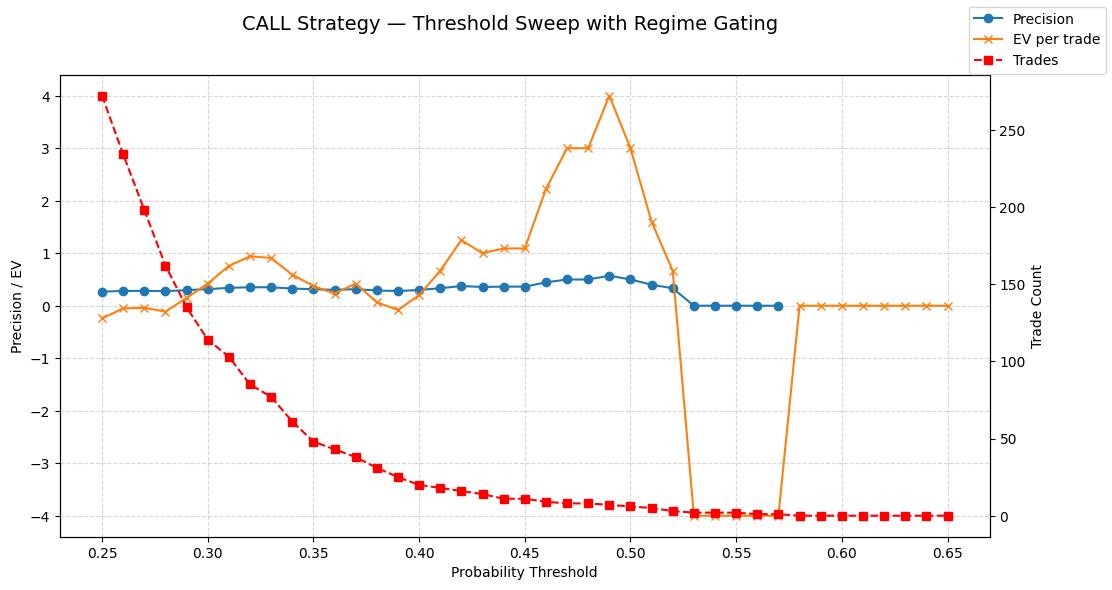

In [6]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Precision / EV")
ax1.plot(df_res["threshold"], df_res["precision"], marker="o", label="Precision")
ax1.plot(df_res["threshold"], df_res["ev"], marker="x", label="EV per trade")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylabel("Trade Count")
ax2.plot(df_res["threshold"], df_res["trades"], linestyle="--", marker="s", color="red", label="Trades")

fig.suptitle("CALL Strategy — Threshold Sweep with Regime Gating", fontsize=14)
fig.legend(loc="upper right")
plt.show()

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# TP/SL config
TP = 10
SL = 4

# Threshold sweep
thresholds = np.arange(0.25, 0.66, 0.01)
results = []

for thresh in thresholds:
    signals = (p_val >= thresh).astype(int)
    trades_taken = signals.sum()
    
    if trades_taken == 0:
        precision = 0
        recall = 0
        ev = 0
    else:
        # precision: only consider fired trades
        y_true_filtered = y_call_val[signals == 1]
        precision = precision_score(y_true_filtered, np.ones_like(y_true_filtered))
        
        # recall: fraction of all positives captured
        recall = recall_score(y_call_val, signals)
        
        # EV calculation
        wins = y_true_filtered.sum()
        losses = trades_taken - wins
        ev = (wins * TP - losses * SL) / trades_taken

    results.append({
        "threshold": thresh,
        "trades": trades_taken,
        "precision": precision,
        "recall": recall,
        "ev": ev
    })

df_res = pd.DataFrame(results)
df_res.head(10)

,threshold,trades,precision,recall,ev
0,0.25,1399,0.310936,0.492081,0.353109
1,0.26,1165,0.325322,0.428733,0.554506
2,0.27,975,0.334359,0.368778,0.681026
3,0.28,812,0.348522,0.320136,0.879310
4,0.29,685,0.364964,0.282805,1.109489
5,0.30,566,0.381625,0.244344,1.342756
6,0.31,489,0.382413,0.211538,1.353783
7,0.32,413,0.387409,0.180995,1.423729
8,0.33,351,0.393162,0.156109,1.504274
9,0.34,285,0.400000,0.128959,1.600000


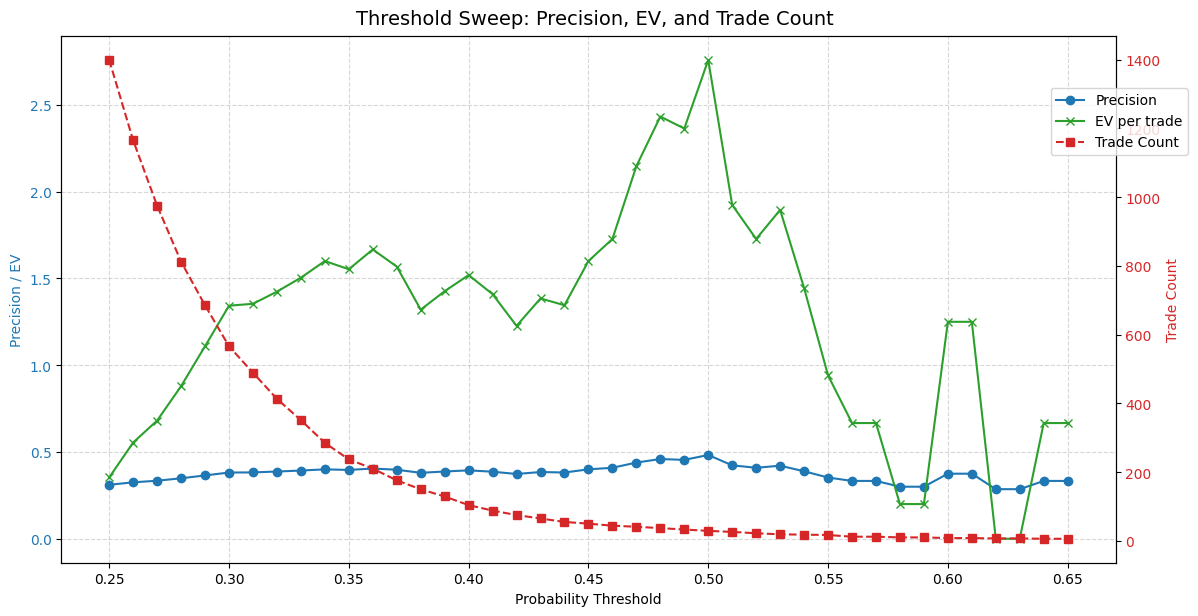

In [8]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Precision / EV", color='tab:blue')
ax1.plot(df_res["threshold"], df_res["precision"], label="Precision", color='tab:blue', marker='o')
ax1.plot(df_res["threshold"], df_res["ev"], label="EV per trade", color='tab:green', marker='x')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylabel("Trade Count", color='tab:red')
ax2.plot(df_res["threshold"], df_res["trades"], label="Trade Count", color='tab:red', linestyle='--', marker='s')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
fig.suptitle("Threshold Sweep: Precision, EV, and Trade Count", fontsize=14, y=1.02)
fig.legend(loc="upper right", bbox_to_anchor=(1,0.9))

plt.show()

In [10]:
import pandas as pd
import numpy as np
import glob

DATA_DIR = "labeled_data"

def load_all_days(data_dir):
    files = sorted(glob.glob(f"{data_dir}/MERGED_*.csv"))
    dfs = []

    for f in files:
        df = pd.read_csv(f)
        df["datetime"] = pd.to_datetime(df["datetime"])
        df["date"] = df["datetime"].dt.date
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df_full = load_all_days(DATA_DIR)

# Apply SAME intraday filter
df_full = df_full[
    (df_full["minutes_from_open"] >= 15) &
    (df_full["minutes_from_open"] <= 365)
]

df_full = df_full.dropna()
print("Reloaded filtered shape:", df_full.shape)

Reloaded filtered shape: (11104, 30)


In [11]:
# Rebuild date splits exactly as before
dates = sorted(df_full["date"].unique())
split_idx = int(len(dates) * 0.7)

val_dates = dates[split_idx:]

# Extract validation rows
df_val_full = df_full[df_full["date"].isin(val_dates)].reset_index(drop=True)

print("df_val_full:", df_val_full.shape)
print("X_val:", X_val.shape)

df_val_full: (3396, 30)
X_val: (3396, 14)


In [12]:
# Attach date to validation frame
df_eval = pd.DataFrame({
    "date": df_val_full["date"].values,
    "p_call": p_val,
    "y_true": y_call_val
})

In [37]:
TP = 10
SL = 4
THRESH = 0.35 # adjust

df_eval["signal"] = (df_eval["p_call"] >= THRESH).astype(int)
df_trades = df_eval[df_eval["signal"] == 1]

def daily_stats(day_df):
    trades = len(day_df)
    wins = day_df["y_true"].sum()
    losses = trades - wins

    ev = (wins * TP - losses * SL) / trades if trades > 0 else np.nan

    return pd.Series({
        "trades": trades,
        "wins": wins,
        "losses": losses,
        "win_rate": wins / trades if trades > 0 else np.nan,
        "ev": ev
    })

daily = df_trades.groupby("date").apply(daily_stats).reset_index()
daily.head()

/var/folders/17/v0pxnrtj3gj1971433dsm4yc0000gn/T/ipykernel_17012/2789068781.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = df_trades.groupby("date").apply(daily_stats).reset_index()


,date,trades,wins,losses,win_rate,ev
0,2026-01-05,6.0,4.0,2.0,0.666667,5.333333
1,2026-01-06,2.0,1.0,1.0,0.500000,3.000000
2,2026-01-07,7.0,2.0,5.0,0.285714,0.000000
3,2026-01-08,2.0,1.0,1.0,0.500000,3.000000
4,2026-01-09,34.0,17.0,17.0,0.500000,3.000000


In [38]:
print("Trading days:", len(daily))
print("Avg trades/day:", round(daily["trades"].mean(), 2))
print("Median EV/day:", round(daily["ev"].median(), 2))
print("Positive EV days %:", round((daily["ev"] > 0).mean(), 2))

print("\nWorst days:")
display(daily.sort_values("ev").head(5))

print("\nBest days:")
display(daily.sort_values("ev", ascending=False).head(5))

Trading days: 9
Avg trades/day: 26.33
Median EV/day: 1.68
Positive EV days %: 0.78

Worst days:


,date,trades,wins,losses,win_rate,ev
8,2026-01-16,24.0,5.0,19.0,0.208333,-1.083333
2,2026-01-07,7.0,2.0,5.0,0.285714,0.000000
5,2026-01-12,52.0,20.0,32.0,0.384615,1.384615
7,2026-01-14,36.0,14.0,22.0,0.388889,1.444444
6,2026-01-13,74.0,30.0,44.0,0.405405,1.675676



Best days:


,date,trades,wins,losses,win_rate,ev
0,2026-01-05,6.0,4.0,2.0,0.666667,5.333333
1,2026-01-06,2.0,1.0,1.0,0.500000,3.000000
3,2026-01-08,2.0,1.0,1.0,0.500000,3.000000
4,2026-01-09,34.0,17.0,17.0,0.500000,3.000000
6,2026-01-13,74.0,30.0,44.0,0.405405,1.675676


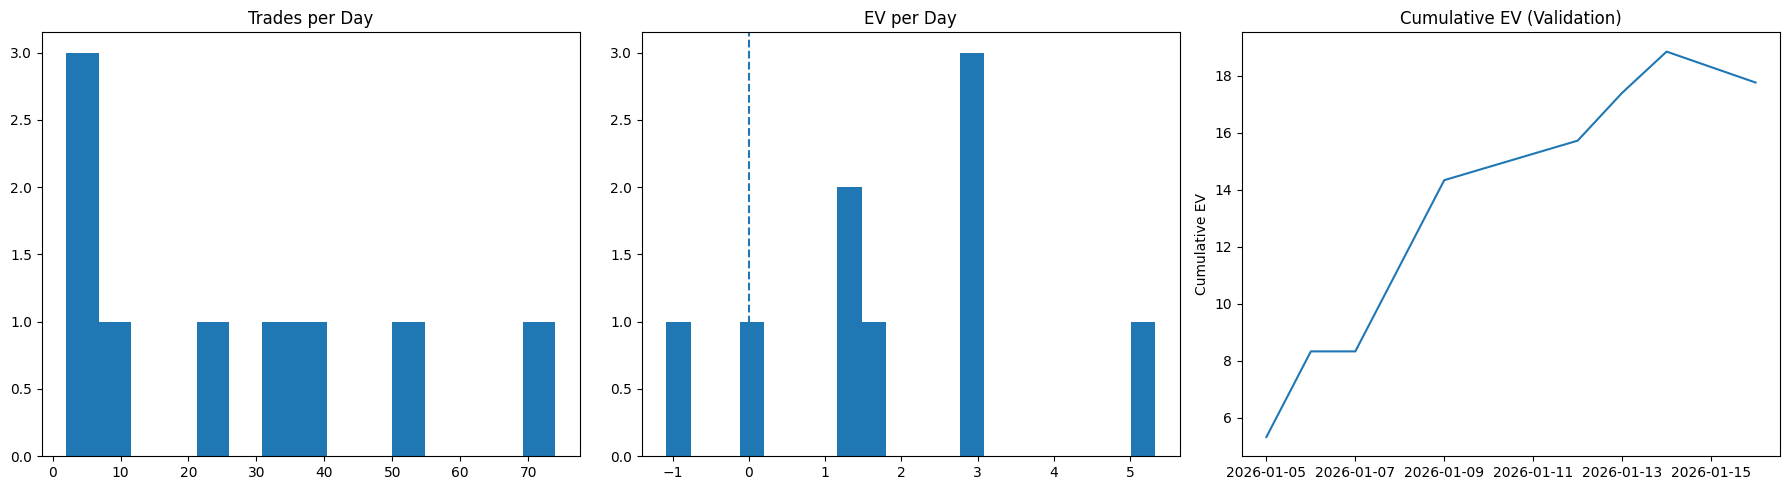

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Trades/day
axes[0].hist(daily["trades"], bins=15)
axes[0].set_title("Trades per Day")

# EV/day
axes[1].hist(daily["ev"], bins=20)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("EV per Day")

# Cumulative EV
daily_sorted = daily.sort_values("date")
axes[2].plot(daily_sorted["date"], daily_sorted["ev"].cumsum())
axes[2].set_title("Cumulative EV (Validation)")
axes[2].set_ylabel("Cumulative EV")

plt.tight_layout()
plt.show()

In [45]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Load data
X_train = pd.read_csv("Dataset/X_train.csv")
X_val   = pd.read_csv("Dataset/X_val.csv")

y_put_train = pd.read_csv("Dataset/y_put_train.csv").values.ravel()
y_put_val   = pd.read_csv("Dataset/y_put_val.csv").values.ravel()

print("Raw Train:", X_train.shape, "Raw Val:", X_val.shape)

# =========================
# PUT REGIME DEFINITION
# =========================

put_regime_train = (
    (X_train["ret_1"] < 0) &                 # immediate downside
    (X_train["ret_3"] < 0) &                 # short-term momentum
    (X_train["vix_ret_5"] > 0) &             # vol expansion
    (X_train["vix_mom_5"] > 0) &             # sustained VIX move
    (X_train["rv_10"] > X_train["rv_10"].median()) &  # active market
    (X_train["minutes_from_open"] < 300)     # avoid EOD decay
)

put_regime_val = (
    (X_val["ret_1"] < 0) &
    (X_val["ret_3"] < 0) &
    (X_val["vix_ret_5"] > 0) &
    (X_val["vix_mom_5"] > 0) &
    (X_val["rv_10"] > X_val["rv_10"].median()) &
    (X_val["minutes_from_open"] < 300)
)

X_put_train = X_train.loc[put_regime_train].copy()
y_put_train_f = y_put_train[put_regime_train]

X_put_val = X_val.loc[put_regime_val].copy()
y_put_val_f = y_put_val[put_regime_val]

print("PUT Regime Train shape:", X_put_train.shape)
print("PUT Regime Val shape:", X_put_val.shape)

print("\nPUT label distribution (train, regime-only):")
print(pd.Series(y_put_train_f).value_counts(normalize=True))

Raw Train: (7708, 14) Raw Val: (3396, 14)
PUT Regime Train shape: (447, 14)
PUT Regime Val shape: (229, 14)

PUT label distribution (train, regime-only):
0    0.689038
1    0.310962
Name: proportion, dtype: float64


In [46]:
pipe_put = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1
    ))
])

pipe_put.fit(X_put_train, y_put_train_f)

p_put_val = pipe_put.predict_proba(X_put_val)[:, 1]

ap_put = average_precision_score(y_put_val_f, p_put_val)
print("Average Precision (PUT, regime-filtered):", round(ap_put, 4))



Average Precision (PUT, regime-filtered): 0.3799


In [47]:
TP = 10
SL = 4

thresholds = np.arange(0.25, 0.66, 0.01)
results_put = []

for thresh in thresholds:
    signals = (p_put_val >= thresh).astype(int)
    trades = signals.sum()

    if trades == 0:
        precision = recall = ev = 0
    else:
        y_true = y_put_val_f[signals == 1]

        precision = y_true.mean()
        recall = (y_true.sum() / y_put_val_f.sum()) if y_put_val_f.sum() > 0 else 0

        wins = y_true.sum()
        losses = trades - wins
        ev = (wins * TP - losses * SL) / trades

    results_put.append({
        "threshold": thresh,
        "trades": trades,
        "precision": precision,
        "recall": recall,
        "ev": ev
    })

df_put = pd.DataFrame(results_put)
df_put.head()

,threshold,trades,precision,recall,ev
0,0.25,170,0.311765,0.803030,0.364706
1,0.26,156,0.314103,0.742424,0.397436
2,0.27,149,0.315436,0.712121,0.416107
3,0.28,138,0.318841,0.666667,0.463768
4,0.29,121,0.322314,0.590909,0.512397


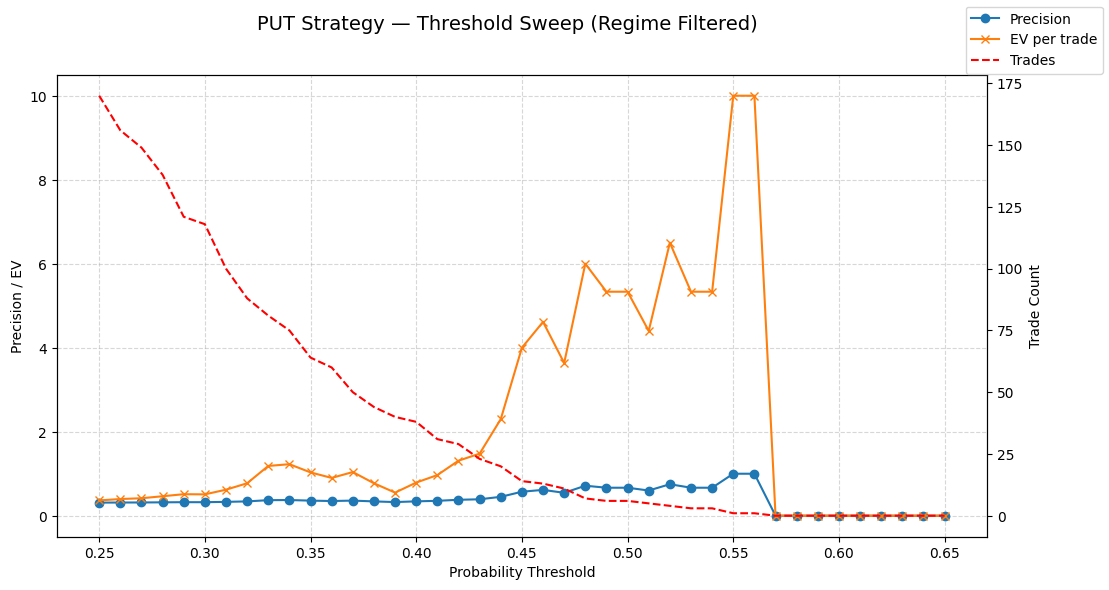

In [48]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Precision / EV")
ax1.plot(df_put["threshold"], df_put["precision"],
         label="Precision", marker="o")
ax1.plot(df_put["threshold"], df_put["ev"],
         label="EV per trade", marker="x")

ax2 = ax1.twinx()
ax2.set_ylabel("Trade Count")
ax2.plot(df_put["threshold"], df_put["trades"],
         label="Trades", linestyle="--", color="red")

ax1.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("PUT Strategy — Threshold Sweep (Regime Filtered)", fontsize=14)
fig.legend(loc="upper right")
plt.show()

In [50]:
import pandas as pd
import numpy as np
import glob

DATA_DIR = "labeled_data"

# -----------------------------
# Load all merged days
# -----------------------------
def load_all_days(data_dir):
    files = sorted(glob.glob(f"{data_dir}/MERGED_*.csv"))
    dfs = []

    for f in files:
        df = pd.read_csv(f)
        df["datetime"] = pd.to_datetime(df["datetime"])
        df["date"] = df["datetime"].dt.date
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df_full = load_all_days(DATA_DIR)

# -----------------------------
# Apply SAME intraday filter
# -----------------------------
df_full = df_full[
    (df_full["minutes_from_open"] >= 15) &
    (df_full["minutes_from_open"] <= 365)
]

df_full = df_full.dropna().reset_index(drop=True)

print("Reloaded filtered shape:", df_full.shape)

# -----------------------------
# Rebuild date splits (EXACT)
# -----------------------------
dates = sorted(df_full["date"].unique())
split_idx = int(len(dates) * 0.7)

val_dates = dates[split_idx:]

# -----------------------------
# Extract validation rows
# -----------------------------
df_val_full = df_full[df_full["date"].isin(val_dates)].reset_index(drop=True)

print("df_val_full:", df_val_full.shape)
print("X_val:", X_val.shape)

# -----------------------------
# SAFETY CHECK (important)
# -----------------------------
assert len(df_val_full) == len(X_val), \
    "Mismatch between df_val_full and X_val rows!"

# -----------------------------
# SAVE FULL VALIDATION DATAFRAME
# -----------------------------
df_val_full.to_csv("Dataset/val_full_df.csv", index=False)

print("✅ Saved: Dataset/val_full_df.csv")

Reloaded filtered shape: (11104, 30)
df_val_full: (3396, 30)
X_val: (3396, 14)
✅ Saved: Dataset/val_full_df.csv


In [54]:
import numpy as np
import pandas as pd

# ----------------------------
# Load validation data WITH dates
# ----------------------------
X_val = pd.read_csv("Dataset/X_val.csv")
y_call_val = pd.read_csv("Dataset/y_call_val.csv").values.ravel()
y_put_val  = pd.read_csv("Dataset/y_put_val.csv").values.ravel()

# IMPORTANT: reload original dataframe to get datetime/date
df_val = pd.read_csv("Dataset/val_full_df.csv")  # must contain datetime + features
df_val["datetime"] = pd.to_datetime(df_val["datetime"])
df_val["date"] = df_val["datetime"].dt.date

# ----------------------------
# Predict probabilities
# ----------------------------
p_call = pipe.predict_proba(X_val)[:, 1]
p_put  = pipe_put.predict_proba(X_val)[:, 1]

# ----------------------------
# Thresholds
# ----------------------------
CALL_THRESH = 0.35
PUT_THRESH  = 0.48
MAX_TRADES_PER_DAY = 5

# ----------------------------
# Create raw signals
# ----------------------------
df_val["p_call"] = p_call
df_val["p_put"]  = p_put

df_val["call_signal"] = df_val["p_call"] >= CALL_THRESH
df_val["put_signal"]  = df_val["p_put"]  >= PUT_THRESH

# ----------------------------
# Resolve conflicts + cap trades/day
# ----------------------------
final_signal = []
trade_side   = []  # "CALL", "PUT", or None

daily_trade_count = {}

for idx, row in df_val.iterrows():
    date = row["date"]
    daily_trade_count.setdefault(date, 0)

    # Skip if daily limit hit
    if daily_trade_count[date] >= MAX_TRADES_PER_DAY:
        final_signal.append(0)
        trade_side.append(None)
        continue

    call = row["call_signal"]
    put  = row["put_signal"]

    if call and not put:
        final_signal.append(1)
        trade_side.append("CALL")
        daily_trade_count[date] += 1

    elif put and not call:
        final_signal.append(1)
        trade_side.append("PUT")
        daily_trade_count[date] += 1

    elif call and put:
        # Conflict → choose higher excess confidence
        call_conf = row["p_call"] - CALL_THRESH
        put_conf  = row["p_put"]  - PUT_THRESH

        if call_conf > put_conf:
            final_signal.append(1)
            trade_side.append("CALL")
        else:
            final_signal.append(1)
            trade_side.append("PUT")

        daily_trade_count[date] += 1

    else:
        final_signal.append(0)
        trade_side.append(None)

df_val["final_signal"] = final_signal
df_val["trade_side"]   = trade_side

In [55]:
def compute_ev(row):
    if row["final_signal"] == 0:
        return 0

    if row["trade_side"] == "CALL":
        return TP if row["y_call"] == 1 else -SL

    if row["trade_side"] == "PUT":
        return TP if row["y_put"] == 1 else -SL

df_val["y_call"] = y_call_val
df_val["y_put"]  = y_put_val

df_val["ev"] = df_val.apply(compute_ev, axis=1)

In [56]:
print("Total trades:", df_val["final_signal"].sum())
print("CALL trades:", (df_val["trade_side"] == "CALL").sum())
print("PUT trades:",  (df_val["trade_side"] == "PUT").sum())

print("Total EV:", df_val["ev"].sum())
print("EV per trade:",
      df_val["ev"].sum() / max(1, df_val["final_signal"].sum()))

# Daily EV
daily_ev = df_val.groupby("date")["ev"].sum()

print("\nWorst day EV:", daily_ev.min())
print("Best day EV:", daily_ev.max())

Total trades: 49
CALL trades: 39
PUT trades: 10
Total EV: 42
EV per trade: 0.8571428571428571

Worst day EV: -20
Best day EV: 22


In [57]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [58]:
def get_models():
    models = {}

    # Logistic
    models["LR"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=2000,
            n_jobs=-1
        ))
    ])

    # Random Forest
    models["RF"] = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=50,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    # XGBoost
    models["XGB"] = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    return models

In [59]:
models = get_models()
trained = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model_call = model
    model_put  = get_models()[name]  # fresh instance

    model_call.fit(X_train, y_call_train)
    model_put.fit(X_train, y_put_train)

    trained[name] = {
        "call": model_call,
        "put": model_put
    }


Training LR...

Training RF...

Training XGB...


In [60]:
TP = 10
SL = 4
THRESH = 0.35  # start fixed

def evaluate_combined(p_call, p_put, y_call, y_put):
    trades = []
    total_ev = 0

    for i in range(len(p_call)):
        call_sig = p_call[i] >= THRESH
        put_sig  = p_put[i]  >= THRESH

        if not call_sig and not put_sig:
            continue

        # conflict resolver
        if call_sig and put_sig:
            side = "call" if p_call[i] >= p_put[i] else "put"
        else:
            side = "call" if call_sig else "put"

        if side == "call":
            win = y_call[i]
        else:
            win = y_put[i]

        ev = TP if win == 1 else -SL
        total_ev += ev
        trades.append(ev)

    return {
        "trades": len(trades),
        "total_ev": total_ev,
        "ev_per_trade": total_ev / len(trades) if trades else 0
    }

In [63]:
results = []

for name, models_pair in trained.items():
    p_call = models_pair["call"].predict_proba(X_val)[:, 1]
    p_put  = models_pair["put"].predict_proba(X_val)[:, 1]

    stats = evaluate_combined(
        p_call, p_put,
        y_call_val,
        y_put_val
    )

    stats["model"] = name
    results.append(stats)

df_results = pd.DataFrame(results)
df_results = df_results[["model", "trades", "total_ev", "ev_per_trade"]]

print("\n=== MODEL COMPARISON ===")
print(df_results.sort_values("ev_per_trade", ascending=False))


=== MODEL COMPARISON ===
  model  trades  total_ev  ev_per_trade
1    RF      72       118      1.638889
0    LR     384       396      1.031250
2   XGB     939       122      0.129925


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np

# Load data
X_train = pd.read_csv("Dataset/X_train.csv")
X_val   = pd.read_csv("Dataset/X_val.csv")

y_call_train = pd.read_csv("Dataset/y_call_train.csv").values.ravel()
y_call_val   = pd.read_csv("Dataset/y_call_val.csv").values.ravel()

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,              # VERY important
    min_samples_leaf=50,      # reduces noise splits
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_call_train)

p_val = rf.predict_proba(X_val)[:, 1]
ap = average_precision_score(y_call_val, p_val)
print("RF AP (CALL):", round(ap, 4))

RF AP (CALL): 0.3184


rv_10                0.153339
minutes_from_open    0.135807
vix_ret_5            0.076592
range                0.069386
close_pos            0.068738
range_pos_30         0.064067
ret_1                0.062096
vix_range            0.060574
range_exp_10         0.056756
vix_range_exp_10     0.056364
ret_3                0.054797
vix_ret_1            0.049358
body_ratio           0.046804
vix_mom_5            0.045322
dtype: float64


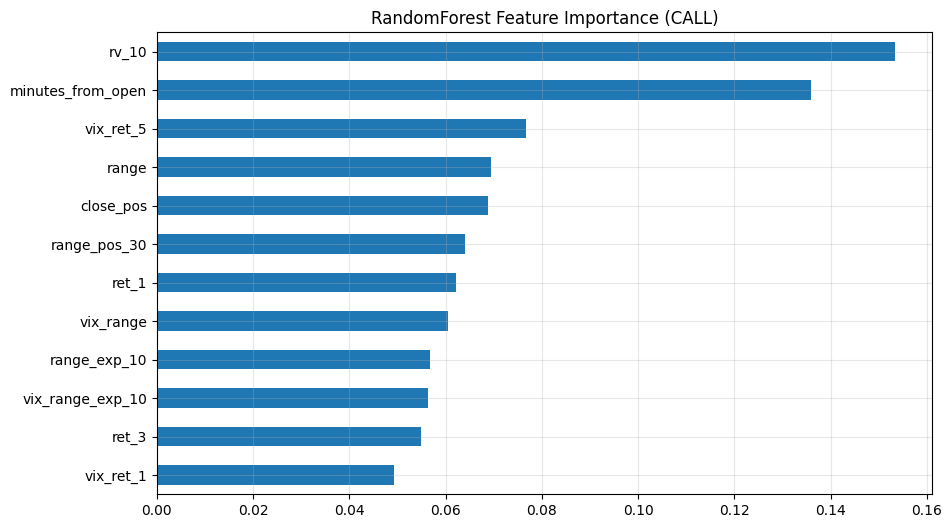

In [65]:
import matplotlib.pyplot as plt

imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(imp)

plt.figure(figsize=(10, 6))
imp.head(12).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RandomForest Feature Importance (CALL)")
plt.grid(alpha=0.3)
plt.show()

In [66]:
import numpy as np

imp_runs = []

for seed in [1, 7, 21, 42, 99]:
    rf_tmp = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )
    rf_tmp.fit(X_train, y_call_train)
    imp_runs.append(rf_tmp.feature_importances_)

imp_df = pd.DataFrame(imp_runs, columns=X_train.columns)
imp_mean = imp_df.mean().sort_values(ascending=False)
imp_std  = imp_df.std()

stable = pd.DataFrame({
    "importance": imp_mean,
    "stability": imp_std
}).sort_values("importance", ascending=False)

stable.head(12)

,importance,stability
rv_10,0.151931,0.002604
minutes_from_open,0.136638,0.004274
vix_ret_5,0.076281,0.002549
range,0.071988,0.004029
close_pos,0.069312,0.001622
range_pos_30,0.064782,0.005513
ret_1,0.062122,0.003016
vix_range,0.057551,0.003511
ret_3,0.057099,0.003831
vix_range_exp_10,0.054848,0.002534


In [67]:
from sklearn.ensemble import RandomForestClassifier

# ---------- RF config ----------
rf_params = dict(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=200,
    n_jobs=-1,
    random_state=42
)

rf_call = RandomForestClassifier(**rf_params)
rf_put  = RandomForestClassifier(**rf_params)

rf_call.fit(X_train, y_call_train)
rf_put.fit(X_train, y_put_train)

# RF probabilities (regime score)
rf_call_train = rf_call.predict_proba(X_train)[:, 1]
rf_call_val   = rf_call.predict_proba(X_val)[:, 1]

rf_put_train  = rf_put.predict_proba(X_train)[:, 1]
rf_put_val    = rf_put.predict_proba(X_val)[:, 1]

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Append RF score as feature
X_train_call_stack = X_train.copy()
X_val_call_stack   = X_val.copy()

X_train_call_stack["rf_score"] = rf_call_train
X_val_call_stack["rf_score"]   = rf_call_val

X_train_put_stack = X_train.copy()
X_val_put_stack   = X_val.copy()

X_train_put_stack["rf_score"] = rf_put_train
X_val_put_stack["rf_score"]   = rf_put_val

In [69]:
def make_lr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            penalty="l2",
            C=0.5,
            solver="lbfgs",
            max_iter=3000
        ))
    ])

lr_call_stack = make_lr()
lr_put_stack  = make_lr()

lr_call_stack.fit(X_train_call_stack, y_call_train)
lr_put_stack.fit(X_train_put_stack, y_put_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5


In [70]:
p_call_stack = lr_call_stack.predict_proba(X_val_call_stack)[:, 1]
p_put_stack  = lr_put_stack.predict_proba(X_val_put_stack)[:, 1]

In [80]:
RF_GATE = 0.15   # tune later

call_gate = rf_call_val >= RF_GATE
put_gate  = rf_put_val  >= RF_GATE

CALL_THRESH = 0.25
PUT_THRESH  = 0.25

call_signal = (call_gate & (p_call_stack >= CALL_THRESH)).astype(int)
put_signal  = (put_gate & (p_put_stack  >= PUT_THRESH)).astype(int)

In [81]:
final_signal = np.zeros(len(X_val), dtype=int)

for i in range(len(X_val)):
    if call_signal[i] and not put_signal[i]:
        final_signal[i] = 1      # CALL
    elif put_signal[i] and not call_signal[i]:
        final_signal[i] = -1     # PUT
    elif call_signal[i] and put_signal[i]:
        # choose higher confidence
        if p_call_stack[i] > p_put_stack[i]:
            final_signal[i] = 1
        else:
            final_signal[i] = -1

In [82]:
TP = 10
SL = 4

evs = []

for i, sig in enumerate(final_signal):
    if sig == 1:
        evs.append(TP if y_call_val.iloc[i] == 1 else -SL)
    elif sig == -1:
        evs.append(TP if y_put_val.iloc[i] == 1 else -SL)

total_trades = len(evs)
total_ev = sum(evs)

print("STACKED RF→LR RESULTS")
print("Trades:", total_trades)
print("Total EV:", total_ev)
print("EV per trade:", round(total_ev / max(1, total_trades), 2))

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'